# 01 — Extração e triagem de escopo

**Entrada:** `AKCIT/MedPT` no HuggingFace (384k+ Q&A de interações reais paciente–médico).
**Saída:** `../data/pares_avaliados.jsonl` (todos os pares julgados, com justificativa) e `../data/corpus_escopo.parquet`.

Este notebook faz chamadas pagas de API. Ele grava cache em disco e não deve ser
re-executado para ajustar decisões das etapas seguintes.

In [1]:
from pathlib import Path
import json

import duckdb
import pandas as pd

DATA = Path.cwd().parent / "data"
DATA.mkdir(exist_ok=True)
PARES_AVALIADOS = DATA / "pares_avaliados.jsonl"
PARES_LEGACY = DATA / "pares_selecionados.legacy.json"
CORPUS_ESCOPO = DATA / "corpus_escopo.parquet"

SEED = 42
con = duckdb.connect()

Vamos usar o **MedPT**, dataset construído com interações reais entre pacientes e médicos.
A lib `duckdb` permite consultar os parquets direto no HuggingFace, sem baixar tudo.

In [2]:
medpt = con.sql("""
     SELECT *
       FROM 'hf://datasets/AKCIT/MedPT/**/*.parquet'
""").df()

print(f"{len(medpt):,} linhas | colunas: {list(medpt.columns)}")

384,095 linhas | colunas: ['id', 'question', 'answer', 'condition', 'medical_specialty', 'question_type']


As colunas `question` e `answer` são as que alimentam o fine-tuning. Mas 384k+ perguntas
é grande demais para o escopo do exercício, então precisamos filtrar.

Seguindo a temática dos dois primeiros Tech Challenges, tratamos de **saúde da mulher**,
simulando um **hospital maternidade**: avaliação pré e neonatal. As colunas
`medical_specialty`, `condition` e `question_type` permitem chegar a um corpus viável
por filtragem estruturada.

Nosso primeiro passo será extrair todas as linhas que contém pelo menos uma especialidade entre 'Ginecologista' e 'Pediatra'. A coluna de especialidades pode possuir múltiplas especialidades, portanto a seleção incluir todas as outras especialidades que "tocam" nas duas principais.

In [3]:
speciality_ranking = con.sql("""
     SELECT trim(esp) AS especialidade,
            COUNT(*) AS n
       FROM medpt,
            UNNEST(string_split(medical_specialty, ',')) AS t(esp)
      WHERE medical_specialty ILIKE '%Pediatra%'
         OR medical_specialty ILIKE '%Ginecologista%'
      GROUP BY 1
      ORDER BY 2 DESC
""").df()

speciality_ranking.head(10)

,especialidade,n
0,Ginecologista,29309
1,Pediatra,12802
2,Mastologista,1030
3,Homeopata,939
4,Endocrinologista pediátrico,786
5,Alergista,745
6,Geneticista,513
7,Sexólogo,511
8,Hematologista pediátrico,476
9,Generalista,428


In [4]:
speciality_ranking['n'].sum()

np.int64(53286)

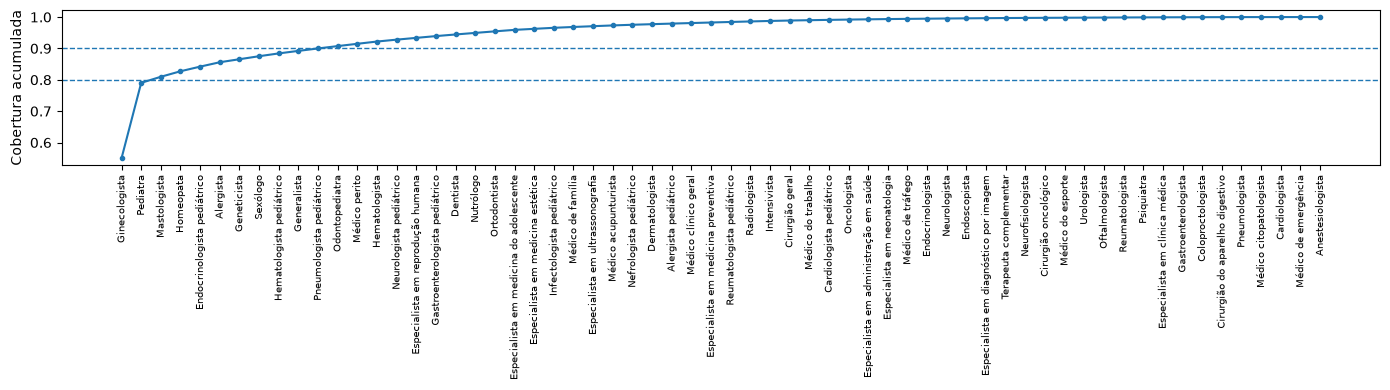

In [5]:
speciality_ranking["acum"] = (
    speciality_ranking["n"].cumsum() / speciality_ranking["n"].sum()
)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 4))
speciality_ranking["acum"].plot(ax=ax, marker="o", markersize=3)
ax.axhline(0.8, ls="--", lw=1)
ax.axhline(0.9, ls="--", lw=1)
ax.set_xticks(range(len(speciality_ranking)))
ax.set_xticklabels(speciality_ranking["especialidade"], rotation=90, fontsize=7)
ax.set_ylabel("Cobertura acumulada")
plt.tight_layout()

In [6]:
conditions_mspecialtys = con.sql("""
    SELECT condition,
           medical_specialty,
           COUNT(*) AS n
      FROM medpt
     WHERE medical_specialty ILIKE '%Pediatra%'
        OR medical_specialty ILIKE '%Ginecologista%'
     GROUP BY 1, 2
     ORDER BY n DESC
""").df()

pairs = list(zip(conditions_mspecialtys["condition"],
                 conditions_mspecialtys["medical_specialty"]))

print(f"{len(pairs):,} pares (condition, medical_specialty) a julgar")
conditions_mspecialtys.head(10)

4,342 pares (condition, medical_specialty) a julgar


,condition,medical_specialty,n
0,HPV,Ginecologista,1968
1,Gravidez,Ginecologista,1895
2,Mioma,Ginecologista,1481
3,Sífilis,Ginecologista,1368
4,Endometriose,Ginecologista,1313
5,Distúrbios Menstruais,Ginecologista,1172
6,Cistos Ovarianos,Ginecologista,882
7,Coronavírus COVID-19,Pediatra,839
8,Constipação em bebês,Pediatra,833
9,Síndrome do ovário policístico - SOP,Ginecologista,794


## Decisão — por que o juiz recebe exemplos de Q&A

A primeira versão deste notebook julgava o escopo a partir **apenas do rótulo**:
`("Constipação em bebês", "Pediatra")`. Para `Pré-eclâmpsia` o rótulo basta. Para
`Febre em crianças` ou `Coronavírus COVID-19` não — essas condições contêm pergunta
de recém-nascido e de criança de 6 anos no mesmo balde, e o rótulo não distingue o
que ele próprio não separa.

Passamos a amostrar `K_EXEMPLOS` perguntas reais de cada par e mostrá-las ao juiz.
Mesmo número de chamadas, mais tokens por chamada, veredito mais informado.

**Limite conhecido:** se a condição for internamente heterogênea, nenhum `K` resolve —
um veredito por par continua forçando um sim/não sobre um balde misto. O diff contra
o `legacy`, mais adiante, mostra quantas condições mudaram de lado; se muitas mudarem
*e* forem justamente as ambíguas, o próximo passo é julgamento linha a linha.

**Botões desta etapa:** `K_EXEMPLOS`, `TRUNCA_RESPOSTA` e a redação do `SYSTEM`.

In [7]:
K_EXEMPLOS = 5          # quantas perguntas reais mostrar ao juiz por par
TRUNCA_RESPOSTA = 300   # chars de answer por exemplo (0 = nao mostrar resposta)

alvo = set(pairs)
exemplos_por_par = {
    chave: grupo.sample(min(K_EXEMPLOS, len(grupo)), random_state=SEED)
    for chave, grupo in medpt.groupby(["condition", "medical_specialty"])
    if chave in alvo
}

def formata_exemplos(par):
    grupo = exemplos_por_par.get(par)
    if grupo is None or len(grupo) == 0:
        return "(sem exemplos disponiveis)"
    linhas = []
    for i, row in enumerate(grupo.itertuples(), 1):
        linhas.append(f"{i}. P: {str(row.question).strip()}")
        if TRUNCA_RESPOSTA:
            linhas.append(f"   R: {str(row.answer).strip()[:TRUNCA_RESPOSTA]}")
    return "\n".join(linhas)

print(formata_exemplos(pairs[0]))

1. P: Fazendo a retirada do ultero e ovários desaparecem o hpv?
   R: Ola, o vírus HPV pode se manifestar na vulva, vagina, ânus e ainda em outras regiões do corpo, portanto a retirada de útero e ovários não traz proteção contra este vírus. o Ideal é sempre manter rotina de avaliação personalizada com o ginecologista. Abs
2. P: Só é possível transmitir o HPV se o indivíduo tiver lesões e verrugas ou uma vez com o vírus, mesmo que inativo, ele será transmitido?
   R: Olá. A infecção pelo HPV pode ser dividida em:1) infecção clínica: é a presença de verrugas e tem tratamento;2) infecção subclinica: é a presença de lesões no colo uterino,3)infecção latente: é a presença do HPV sem verrugas e sem lesões no colo uterino e não tem tratamento.A presença de lesões pelo
3. P: Pode ser feito exame de captura híbrida para hps em colo uterino e logo depois biopsia do colo uterino juntos?
   R: Sim, é possível realizar o exame de captura híbrida para HPV (Papilomavírus Humano) e a biópsia do colo d

In [8]:
import os
from dotenv import load_dotenv
from openai import AsyncOpenAI

load_dotenv()
if not os.getenv("Z_API_KEY"):
    raise RuntimeError("Z_API_KEY ausente. Defina no .env (veja .env.example).")

client = AsyncOpenAI(
    api_key=os.getenv("Z_API_KEY"),
    base_url="https://api.z.ai/api/paas/v4/",
)

O schema abaixo declara `required` e `additionalProperties: False`, e as chaves são
exatamente as que o código lê adiante. 

O campo `motivo` existe para que a curadoria seja auditável: sem ele não há como
responder "por que essa condição ficou de fora?" nem depurar o juiz.

In [ ]:
from enum import Enum
from pydantic import BaseModel, Field

class Escopos(int, Enum):
    SIM = 1
    NAO = 0

class Judgement(BaseModel):
    escopo: Escopos = Field(description='1 se a condicao pertence ao universo da maternidade, 0 caso contrario')
    motivo: str = Field(description='justificativa curta, em uma frase')


def formato_esperado(modelo: type[BaseModel]) -> str:
    """Renderiza o modelo como TEMPLATE de saida, nao como JSON Schema.

    Colar o `model_json_schema()` cru no prompt faz o modelo copiar o schema
    inteiro na resposta e anexar os campos reais no fim. O template abaixo
    mostra so as chaves, os valores de enum e a descricao de cada campo.
    """
    schema = modelo.model_json_schema()
    defs = schema.get("$defs", {})
    campos = {}
    for nome, prop in schema["properties"].items():
        if "$ref" in prop:
            prop = defs[prop["$ref"].split("/")[-1]] | prop
        if "enum" in prop:
            campos[nome] = " | ".join(str(v) for v in prop["enum"])
        else:
            campos[nome] = f"<{prop.get('description', prop['type'])}>"
    return json.dumps(campos, ensure_ascii=False, indent=2)


SYSTEM = (
    "Voce e um medico que atua em um hospital maternidade, acompanhando "
    "gestantes, puerperas e bebes ate 1 ano.\n\n"
    "Tarefa: decidir se uma condicao medica pertence ao escopo de atendimento "
    "desse hospital. Voce recebe a condicao, a especialidade e alguns exemplos "
    "reais de perguntas feitas sobre essa condicao. Os exemplos mostram como a "
    "condicao aparece na pratica; use-os para desambiguar rotulos genericos.\n\n"
    "O escopo cobre:\n"
    "- fertilidade e planejamento reprodutivo\n"
    "- gestacao e suas complicacoes\n"
    "- parto\n"
    "- puerperio e amamentacao\n"
    "- bebe ate 1 ano de idade\n\n"
    "CRITERIO. Responda 1 quando pelo menos uma for verdadeira:\n"
    "(a) a condicao so ocorre na gestacao, no parto, no puerperio ou no "
    "recem-nascido;\n"
    "(b) a condicao ocorre tambem fora desse contexto, mas o diagnostico, a "
    "conduta ou o risco mudam de forma relevante quando a paciente esta "
    "gestante ou quando o paciente e um bebe ate 1 ano.\n\n"
    "Responda 0 quando a condicao apenas pode coexistir com a gestacao ou com "
    "o primeiro ano de vida sem que isso altere o manejo, e quando ela nao "
    "pertence a nenhuma das fases acima.\n\n"
    "PAPEL DOS EXEMPLOS. Se os exemplos mostrarem que as perguntas reais sobre "
    "essa condicao tratam majoritariamente de pacientes fora do escopo (criancas "
    "maiores de 1 ano, mulheres fora do ciclo gravidico-puerperal), responda 0 "
    "mesmo que o rotulo da condicao pareca pertinente.\n\n"
    "PAPEL DA ESPECIALIDADE. A condicao decide primeiro. Use a especialidade "
    "apenas para desempatar condicoes ambiguas.\n\n"
    "Exemplos de veredito:\n"
    "Pre-eclampsia | Ginecologista -> 1\n"
    "Asfixia Neonatal | Oncologista, Pediatra -> 1\n"
    "Infeccao Urinaria | Ginecologista -> 1\n"
    "Constipacao em bebes | Pediatra -> 1\n"
    "Menopausa | Ginecologista -> 0\n"
    "Escoliose | Pediatra -> 0\n"
    "Labirintite | Ginecologista -> 0\n\n"
    "Responda apenas o JSON abaixo preenchido, exatamente com estas duas chaves, "
    "sem texto antes ou depois:\n"
    f"{formato_esperado(Judgement)}"
)

`classify` tem backoff exponencial, portanto uma falha de rede não perde o par silenciosamente.

A função devolve um **registro**, com todas as informações necessárias para filtragens posteriores.

In [15]:
import asyncio
import random
import re

def parse_json(texto: str):
    limpo = re.sub(r"^```(?:json)?\s*|\s*```$", "", texto.strip()).strip()
    return json.loads(limpo)

CONCORRENCIA = 50
MODELO_JUIZ = "glm-5.3-flash"
sem = asyncio.Semaphore(CONCORRENCIA)

async def classify(par, tentativas=4):
    cond, esp = par
    user = (
        f"Condicao: {cond} | Especialidade: {esp}\n\n"
        f"Exemplos reais de perguntas sobre essa condicao:\n{formata_exemplos(par)}"
    )
    base = {
        "condition": cond,
        "medical_specialty": esp,
        "n_exemplos": len(exemplos_por_par.get(par, [])),
    }
    async with sem:
        for tentativa in range(tentativas):
            try:
                resp = await client.chat.completions.create(
                    model=MODELO_JUIZ,
                    messages=[
                        {"role": "system", "content": SYSTEM},
                        {"role": "user", "content": user},
                    ],
                    response_format={
                        "type": "json_schema",
                        "json_schema": {"name": "Judgement", "schema": Judgement.model_json_schema(), "strict": True}
                    },
                    temperature=0,
                )
                r = parse_json(resp.choices[0].message.content)
                print(r)

                return base | {"escopo": int(r["escopo"]), "motivo": r.get("motivo", "")}
            except Exception as erro:
                if tentativa == tentativas - 1:
                    return base | {"escopo": None, "motivo": f"ERRO: {type(erro).__name__}: {erro}"}
                await asyncio.sleep(2 ** tentativa + random.random())

In [17]:
# Cache em disco: a triagem custa dinheiro e nao deve rodar de novo sem intencao.
if PARES_AVALIADOS.exists():
    avaliados = [json.loads(l) for l in PARES_AVALIADOS.read_text(encoding="utf-8").splitlines() if l.strip()]
    print(f"Cache carregado: {len(avaliados)} pares. Apague {PARES_AVALIADOS.name} para re-julgar.")
else:
    avaliados = await asyncio.gather(*(classify(p) for p in pairs))
    with PARES_AVALIADOS.open("w", encoding="utf-8") as f:
        for reg in avaliados[:10]:
            f.write(json.dumps(reg, ensure_ascii=False) + "\n")
    print(f"{len(avaliados)} pares julgados e gravados em {PARES_AVALIADOS.name}")

{'escopo': 1, 'motivo': 'A condição ocorre exclusivamente durante a gestação e os exemplos mostram perguntas de gestantes sobre sangramento, ameaça de aborto e complicações típicas da gravidez.'}
{'escopo': 1, 'motivo': 'O sangramento no final da gravidez ocorre exclusivamente no contexto gestacional e exige avaliação obstétrica imediata por risco de trabalho de parto e descolamento, conforme os exemplos de gestantes a termo.'}
{'escopo': 1, 'motivo': 'Infertilidade feminina pertence diretamente ao escopo de fertilidade e planejamento reprodutivo do hospital, e os exemplos mostram mulheres em tentativa de gestação buscando avaliação e tratamento pré-concepcional.'}
{'escopo': 1, 'motivo': 'Gravidez ectópica é uma complicação exclusiva da gestação e as perguntas reais tratam de conduta, risco de recorrência e planejamento reprodutivo, dentro do escopo da maternidade.'}
{'escopo': 1, 'motivo': 'Constipação em bebês afeta diretamente pacientes de até 1 ano, e os exemplos mostram perguntas

In [18]:
avaliados_df = pd.DataFrame(avaliados)

aprovados_df = avaliados_df[avaliados_df["escopo"] == 1]
rejeitados_df = avaliados_df[avaliados_df["escopo"] == 0]

print(f"{len(avaliados_df):,} pares julgados")
print(f"  aprovados:  {len(aprovados_df):,}")
print(f"  rejeitados: {len(rejeitados_df):,}")
print(f"  erros:      {avaliados_df['escopo'].isna().sum():,}")

# Amostra das justificativas dos dois lados -- e o que torna a curadoria auditavel.
for rotulo, subset in [("APROVADOS", aprovados_df), ("REJEITADOS", rejeitados_df)]:
    print(f"\n=== {rotulo} ===")
    for r in subset.sample(min(5, len(subset)), random_state=SEED).itertuples():
        print(f"- {r.condition} ({r.medical_specialty}): {r.motivo}")

4,342 pares julgados
  aprovados:  1,962
  rejeitados: 2,380
  erros:      0

=== APROVADOS ===
- Neurofibromatose 1 (Pediatra): A condicao influencia diretamente o planejamento reprodutivo (risco de herdanca genetica de 50% e orientacao pre-concepcional) e tem manejo modificado na gestacao, como mostrado no exemplo de pergunta.
- Doença valvular cardíaca (Pediatra): Os exemplos mostram avaliação de válvulas fetais no Doppler pré-natal, e a doença valvar na gestante exige conduta específica (estratificação de risco, anticoagulação, planejamento do parto), alterando o manejo no contexto da maternidade.
- Distúrbio do sono infantil (Pediatra, Especialista em medicina do adolescente): Os exemplos reais mostram que a maioria das perguntas trata de bebes menores de 1 ano com despertares noturnos, fase em que a avaliacao e a conduta do sono (ciclos, mamadas noturnas, higiene do sono) diferem substancialmente da de criancas maiores, enquadrando a condicao no atendimento do primeiro ano de vid

## Diff contra o juiz anterior

O `legacy` é o resultado da triagem que via apenas o rótulo. Comparar os dois mede o
efeito dos exemplos — e é material direto para a seção de avaliação do relatório.

O que olhar: se as condições que mudaram de lado forem justamente as ambíguas
(`Febre em crianças`, `Coronavírus COVID-19`), os exemplos fizeram o trabalho esperado.
Se condições inequívocas mudaram, o prompt regrediu.

In [19]:
if PARES_LEGACY.exists():
    legacy = {tuple(x) for x in json.loads(PARES_LEGACY.read_text(encoding="utf-8"))}
    novo = set(zip(aprovados_df["condition"], aprovados_df["medical_specialty"]))

    entraram, sairam = novo - legacy, legacy - novo
    print(f"legacy: {len(legacy)} aprovados | novo: {len(novo)} aprovados")
    print(f"entraram: {len(entraram)} | sairam: {len(sairam)} | estaveis: {len(novo & legacy)}\n")

    motivos = avaliados_df.set_index(["condition", "medical_specialty"])["motivo"].to_dict()
    for rotulo, conjunto in [("ENTRARAM", entraram), ("SAIRAM", sairam)]:
        print(f"=== {rotulo} ===")
        for par in list(conjunto)[:15]:
            print(f"- {par[0]} ({par[1]}): {motivos.get(par, '')}")
        print()
else:
    print(f"{PARES_LEGACY.name} ausente — sem diff.")

pares_selecionados.legacy.json ausente — sem diff.


O corpus aprovado segue para `02_curadoria.ipynb`, que aplica os filtros de qualidade,
a anonimização e a política de retenção de duplicatas.

In [20]:
corpus = medpt.merge(
    aprovados_df[["condition", "medical_specialty"]],
    on=["condition", "medical_specialty"],
    how="inner",
)

corpus.to_parquet(CORPUS_ESCOPO, index=False)
print(f"{len(corpus):,} exemplos em {corpus['condition'].nunique()} condições "
      f"e {corpus['medical_specialty'].nunique()} combinações de especialidade")
print(f"→ {CORPUS_ESCOPO.name}")

21,967 exemplos em 662 condições e 125 combinações de especialidade
→ corpus_escopo.parquet
